<>:26: SyntaxWarning: invalid escape sequence '\e'
<>:26: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_402/3141172190.py:26: SyntaxWarning: invalid escape sequence '\e'
  axs[0].plot(x, eps_greedy_pi, label='$\epsilon$-Greedy Policy', linestyle='-.', color='orange')


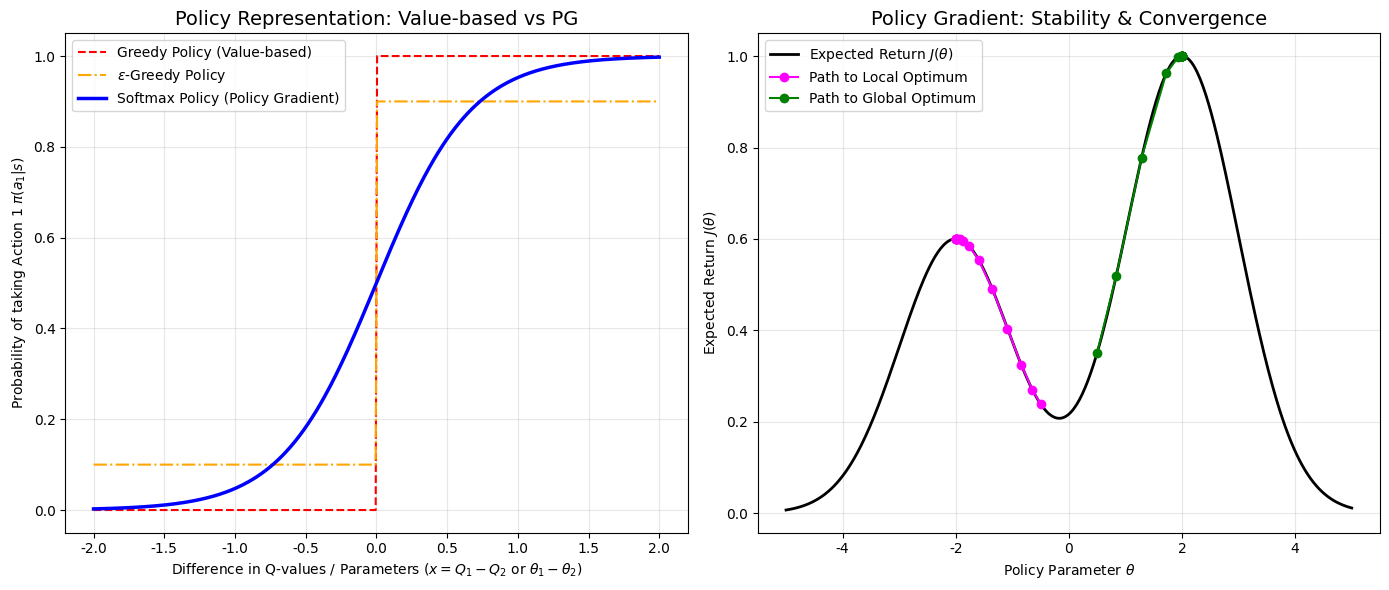

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트 설정 (환경에 따라 깨질 경우 영문으로 대체)
plt.rcParams['axes.unicode_minus'] = False

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# ==========================================
# 1. Value function 근사 vs Policy Gradient
# ==========================================
# 두 행동 간의 가치(Q) 차이 또는 정책 파라미터(Theta) 차이 (x = Q1 - Q2 or Theta1 - Theta2)
x = np.linspace(-2, 2, 400)

# 가치 기반(Value-based) 방식의 정책: Greedy 및 Epsilon-Greedy
# Q값이 조금만 역전되어도 확률이 0에서 1로 급변함 (불안정성의 원인)
greedy_pi = np.where(x > 0, 1.0, 0.0)
epsilon = 0.2
eps_greedy_pi = np.where(x > 0, 1.0 - epsilon/2, epsilon/2)

# Policy Gradient 방식의 정책: Softmax
# 파라미터 변화에 따라 확률이 부드럽게 연속적으로 변함 (안정적인 학습 가능)
softmax_pi = 1 / (1 + np.exp(-x * 3))

axs[0].plot(x, greedy_pi, label='Greedy Policy (Value-based)', linestyle='--', color='red')
axs[0].plot(x, eps_greedy_pi, label='$\epsilon$-Greedy Policy', linestyle='-.', color='orange')
axs[0].plot(x, softmax_pi, label='Softmax Policy (Policy Gradient)', linewidth=2.5, color='blue')

axs[0].set_title('Policy Representation: Value-based vs PG', fontsize=14)
axs[0].set_xlabel('Difference in Q-values / Parameters ($x = Q_1 - Q_2$ or $\\theta_1 - \\theta_2$)')
axs[0].set_ylabel('Probability of taking Action 1 $\\pi(a_1|s)$')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# ==========================================
# 2. PG의 안정성 및 Locally Optimal 수렴 시각화
# ==========================================
# 가상의 Expected Return 목적 함수 J(theta) 설계
# 지역 최적해(Local Optimum)는 theta = -2 부근, 전역 최적해(Global Optimum)는 theta = 2 부근에 존재
def J(theta):
    return 0.6 * np.exp(-0.5 * (theta + 2)**2) + 1.0 * np.exp(-0.5 * (theta - 2)**2)

# J(theta)의 도함수 (Gradient)
def grad_J(theta):
    grad1 = 0.6 * np.exp(-0.5 * (theta + 2)**2) * -(theta + 2)
    grad2 = 1.0 * np.exp(-0.5 * (theta - 2)**2) * -(theta - 2)
    return grad1 + grad2

theta_vals = np.linspace(-5, 5, 400)
J_vals = J(theta_vals)

axs[1].plot(theta_vals, J_vals, color='black', linewidth=2, label='Expected Return $J(\\theta)$')

# Gradient Ascent (경사상승법) 시뮬레이션
alpha = 0.8  # 학습률 (Learning Rate)
num_steps = 15

# 궤적 1: 초기값이 -0.5일 때 -> Local Optimum으로 부드럽게 수렴
theta_path1 = [-0.5]
for _ in range(num_steps):
    theta_path1.append(theta_path1[-1] + alpha * grad_J(theta_path1[-1]))
theta_path1 = np.array(theta_path1)
axs[1].plot(theta_path1, J(theta_path1), 'o-', color='magenta', label='Path to Local Optimum', markersize=6)

# 궤적 2: 초기값이 0.5일 때 -> Global Optimum으로 부드럽게 수렴
theta_path2 = [0.5]
for _ in range(num_steps):
    theta_path2.append(theta_path2[-1] + alpha * grad_J(theta_path2[-1]))
theta_path2 = np.array(theta_path2)
axs[1].plot(theta_path2, J(theta_path2), 'o-', color='green', label='Path to Global Optimum', markersize=6)

axs[1].set_title('Policy Gradient: Stability & Convergence', fontsize=14)
axs[1].set_xlabel('Policy Parameter $\\theta$')
axs[1].set_ylabel('Expected Return $J(\\theta)$')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()